In [1]:
# 导入必要的库
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random

In [2]:
# 检查CUDA是否可用
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Main_path = 'D:\\Desktop\\Desktop\\Python\\Forward_and_Inverse_problem\\'
Data_path = f'{Main_path}Data\\'
save_path = f'{Main_path}Model\\Python_code_FFT_Complex\\'
random.seed(42)

Using device: cuda:0


In [3]:
M = 9900
batch_size = 1
label_dim = 3

criterion = nn.MSELoss().to(device)

# 定义数据集类
class SignalDataset(Dataset):
    def __init__(self, excitation_signals, labels, experimental_signal):
        self.excitation_signals = torch.tensor(excitation_signals, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.experimental_signal = torch.tensor(experimental_signal, dtype=torch.float32)

    def __len__(self):
        return len(self.excitation_signals)

    def __getitem__(self, idx):
        return {
            'excitation_signal': self.excitation_signals[idx],
            'labels': self.labels[idx],
            'experimental_signal': self.experimental_signal[idx]
        }

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, signal_length, label_dim, hidden_dim, dropout):
        super().__init__()
        self.signal_length = signal_length
        self.label_dim = label_dim
        
        # 标签投影网络（7层）
        self.label_projection = nn.Sequential(
            nn.Linear(label_dim, hidden_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim * 8),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 8, hidden_dim * 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 16, hidden_dim * 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 32, hidden_dim * 64),  # 第5层
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 64, hidden_dim * 128), # 第6层
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 128, hidden_dim * 64) # 第7层
        )
        
        # 7层编码器
        self.encoder = nn.Sequential(
            # Layer 1
            nn.Conv1d(1, hidden_dim, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            
            # Layer 2
            nn.Conv1d(hidden_dim, hidden_dim*2, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            
            # Layer 3
            nn.Conv1d(hidden_dim*2, hidden_dim*4, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 4
            nn.Conv1d(hidden_dim*4, hidden_dim*8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 5 - 修改
            nn.Conv1d(hidden_dim*8, hidden_dim*16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            
            # Layer 6 - 修改
            nn.Conv1d(hidden_dim*16, hidden_dim*32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 7 - 修改
            nn.Conv1d(hidden_dim*32, hidden_dim*64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )
        
        # 7层解码器
        self.decoder = nn.Sequential(
            # Layer 1: 融合
            nn.ConvTranspose1d(hidden_dim*64 + hidden_dim*64, hidden_dim*32,  # 标签特征改为64维
                              kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 2
            nn.ConvTranspose1d(hidden_dim*32, hidden_dim*16, 
                              kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            
            # Layer 3
            nn.ConvTranspose1d(hidden_dim*16, hidden_dim*8, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 4
            nn.ConvTranspose1d(hidden_dim*8, hidden_dim*4, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 5
            nn.ConvTranspose1d(hidden_dim*4, hidden_dim*2, 
                              kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            
            # Layer 6
            nn.ConvTranspose1d(hidden_dim*2, hidden_dim, 
                              kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(),
            
            # Layer 7
            nn.ConvTranspose1d(hidden_dim, 1, 
                              kernel_size=7, stride=2, padding=3, output_padding=1),
        )
        
        # 计算编码输出长度
        with torch.no_grad():
            test_input = torch.randn(1, 1, signal_length)
            encoded = self.encoder(test_input)
            self.encoder_output_len = encoded.shape[-1]

    def forward(self, x, labels):
        # 编码
        encoded = self.encoder(x)
        
        # 标签特征
        label_features = self.label_projection(labels)
        label_features = label_features.unsqueeze(-1).expand(-1, -1, self.encoder_output_len)
        
        # 融合和解码
        combined = torch.cat([encoded, label_features], dim=1)
        decoded = self.decoder(combined)
        
        return decoded[:,:,:self.signal_length]

In [5]:
def load_data(excitation_signal_path, experimental_signal_path, M):
    excitation_signals = []  # 存储生成信号
    labels = []  # 存储标签 (Force_label, HI_label, Distance_label, Time_label)
    experimental_signals = []  # 存储输出参数
    filenames = []  # 存储文件名

    # 加载生成信号数据
    excitation_dataPaths = sorted(glob.glob(os.path.join(excitation_signal_path, '**', '*.csv'), recursive=True))
    for dataPath in excitation_dataPaths:
        filename = os.path.basename(dataPath)
        parts = filename.split('_')

        Temperature_label = float(parts[0])
        Time_label = float(parts[1])
        Distance_label = float(parts[4])
        amp_part = parts[5].replace('.csv', '')
        Amp_label = float(amp_part)    

        data_1 = pd.read_csv(dataPath)
        # 找到第一个非0值的位置
        for N in range(len(data_1)):
            if data_1.iloc[N, 1] != 0:
                break
        # 截取长度为M的信号段
        if N + M <= len(data_1):  # 避免越界
            excitation_signal = data_1.iloc[N:N+M, 1].values*Amp_label
        else:
            continue

        # 分别存储 excitation_signal 和 labels
        excitation_signals.append(excitation_signal)
        labels.append([Temperature_label, Time_label, Distance_label])

    # 加载实验信号数据
    experimental_dataPaths = sorted(glob.glob(os.path.join(experimental_signal_path, '**', '*.csv'), recursive=True))
    for dataPath in experimental_dataPaths:
        data_1 = pd.read_csv(dataPath)
        # 找到第一个非0值的位置
        for N in range(len(data_1)):
            if data_1.iloc[N, 1] != 0:
                break
        # 截取长度为M的信号段（避免越界）
        if N + M <= len(data_1):
            experimental_signal = data_1.iloc[N:N+M, 1].values
            experimental_signals.append(experimental_signal)
        else:
            # 如果长度不足，跳过该样本（也可根据需求补0）
            continue

    # 确保 excitation_signals、labels 和 experimental_signals 的长度一致
    if len(excitation_signals) != len(experimental_signals) or len(labels) != len(experimental_signals):
        print(f"Error: 输入输出数量不匹配！生成信号数:{len(excitation_signals)}, 实验信号数:{len(experimental_signals)}, 标签数:{len(labels)}")
        return None, None, None, None, None

    # 转换为 NumPy 数组
    excitation_signals = np.array(excitation_signals, dtype=float)
    labels = np.array(labels, dtype=float)
    experimental_signals = np.array(experimental_signals, dtype=float)

    return excitation_signals, labels, experimental_signals

In [6]:
excitation_signal_path = f'{Data_path}Hanning_Excitation_signal'
experimental_signal_path = f'{Data_path}Experiment_signal'

# 加载数据
filenames = os.listdir(excitation_signal_path)


# 加载数据（假设 load_data 按文件名顺序返回数据）
excitation_signals, labels, experimental_signal = load_data(
    excitation_signal_path, experimental_signal_path,M)

excitation_signals = excitation_signals
labels = labels
experimental_signal = experimental_signal

# 所有数据作为测试集
test_filenames = filenames

# 所有数据分配给测试集
excitation_signals_test = excitation_signals
labels_test = labels
experimental_signal_test = experimental_signal

# 增加一个维度，从 [batch_size, N] 变为 [batch_size, 1, N]
excitation_signals_test = np.expand_dims(excitation_signals_test, axis=1)
experimental_signal_test = np.expand_dims(experimental_signal_test, axis=1)

print(f'excitation_signals_test:{excitation_signals_test.shape}')
print(f'Total test samples: {len(excitation_signals_test)}')

# 只创建测试集数据集和数据加载器
test_dataset = SignalDataset(excitation_signals_test, labels_test, experimental_signal_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 训练集和验证集设为 None（或空列表），避免后续代码报错
train_loader = None
val_loader = None

excitation_signals_test:(864, 1, 9900)
Total test samples: 864


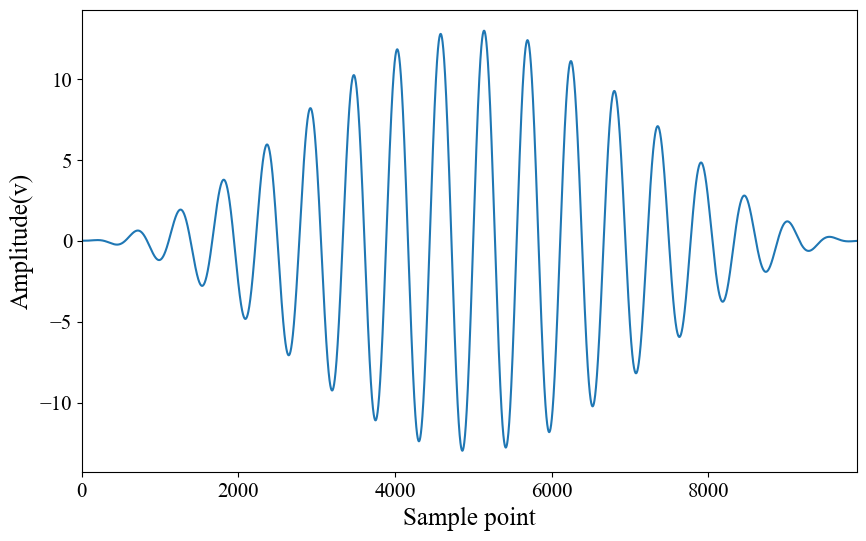

In [7]:
excitation_signals_test_1 = excitation_signals_test.reshape(-1,M,1)
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(excitation_signals_test_1[1],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(v)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{save_path}Forward_problem\\Excitation_signal_test.jpg', dpi=600, bbox_inches='tight')

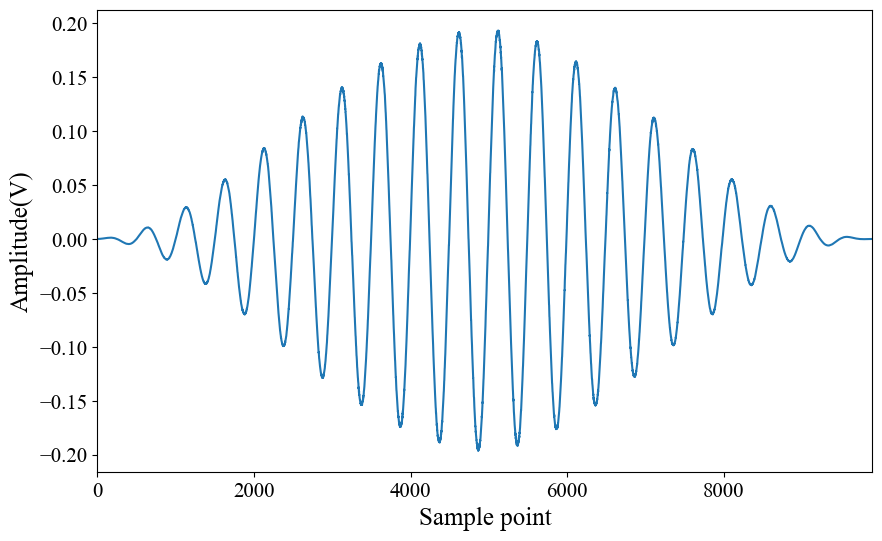

In [8]:
experimental_signal_test_1 = experimental_signal_test.reshape(-1,M,1)
plt.style.use('default')
plt.figure(figsize=(10,6))
plt.rcParams['font.family'] = ['Times New Roman']
plt.plot(experimental_signal_test_1[25],linewidth=1.5)
plt.xlabel('Sample point',fontdict={'weight': 'normal', 'size': 18})
plt.ylabel('Amplitude(V)',fontdict={'weight': 'normal', 'size': 18})
#坐标轴刻度大小设置
plt.tick_params(axis='both', which='major', labelsize=15)
plt.xlim([0,M])
plt.savefig(f'{save_path}Forward_problem\\Experiment_signal_test.jpg', dpi=600, bbox_inches='tight')

In [9]:
# 训练模型
model=torch.load(f'{save_path}Forward_problem\\Forward_Model_FFT_Complex.pth')  # 加载训练好的模型参数
model.to(device)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3612\3074171379.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model=torch.load(f'{save_path}Forward_problem\\Forwar

ConvAutoencoder(
  (label_projection): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0, inplace=False)
    (6): Linear(in_features=128, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0, inplace=False)
    (9): Linear(in_features=256, out_features=512, bias=True)
    (10): ReLU()
    (11): Dropout(p=0, inplace=False)
    (12): Linear(in_features=512, out_features=1024, bias=True)
    (13): ReLU()
    (14): Dropout(p=0, inplace=False)
    (15): Linear(in_features=1024, out_features=2048, bias=True)
    (16): ReLU()
    (17): Dropout(p=0, inplace=False)
    (18): Linear(in_features=2048, out_features=1024, bias=True)
  )
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(5,), stride=(2,), padding=(2,))
    (

In [10]:
def calculate_fft(signal, sampling_rate):
    N = len(signal)  # 信号长度
    fft_values = np.fft.fft(signal)  # 计算FFT
    fft_magnitude = np.abs(fft_values)  # 取模
    fft_magnitude = fft_magnitude[:N // 2]  # 只取一半（正频率部分）
    freq = np.fft.fftfreq(N, d=1 / sampling_rate)[:N // 2]  # 频率轴
    return freq, fft_magnitude

In [11]:
def calculate_pcc(x, y):
    """
    计算两个信号的皮尔逊相关系数(PCC)。

    参数:
        x (torch.Tensor): 第一个信号，假定在 CUDA 上。
        y (torch.Tensor): 第二个信号，假定在 CUDA 上。

    返回:
        float: 皮尔逊相关系数。
    """
    
    # 计算均值
    mean_x = torch.mean(x)
    mean_y = torch.mean(y)
    
    # 计算协方差
    covariance = torch.mean((x - mean_x) * (y - mean_y))
    
    # 计算标准差
    std_x = torch.std(x)
    std_y = torch.std(y)
    
    # 计算皮尔逊相关系数
    if std_x == 0 or std_y == 0:
        raise ValueError("标准差不能为零，这可能导致除以零的错误。")
    
    pcc = covariance / (std_x * std_y)

    pcc_1 = pcc.to(device)

    return pcc_1.item()  # 将结果转换为 Python 标量

In [12]:
pcc_time = 0.0
pcc_fft = 0.0

Error_fft = 0.0

# 采样率
sampling_rate = 2.5e7

signal_predicted = []
signal_origin=[]

running_loss = 0.0
criterion = nn.MSELoss().to(device)

# 将模型设置为评估模式
model.eval()  
# 进行预测
with torch.no_grad():  # 关闭梯度计算
    for batch in test_loader:
        excitation_signal = batch['excitation_signal'].to(device)
        labels = batch['labels'].to(device)
        experimental_signal = batch['experimental_signal'].to(device)

        experimental_signal_pred = model(excitation_signal, labels)
        loss = criterion(experimental_signal_pred, experimental_signal)

        running_loss += loss.item()
        pcc_time += calculate_pcc(experimental_signal_pred,experimental_signal)

        # 将重构信号移动到CPU并转换为NumPy数组
        Origin_x3 = experimental_signal.cpu().numpy().squeeze()
        predicted_x3 = experimental_signal_pred.cpu().numpy().squeeze()

        # 假设 Original_signal 和 predicted_signal 已经定义
        freq_origin, fft_magnitude_origin = calculate_fft(Origin_x3, sampling_rate)
        freq_predicted, fft_magnitude_predicted = calculate_fft(predicted_x3, sampling_rate)

        fft_magnitude_predicted,fft_magnitude_origin=torch.from_numpy(fft_magnitude_predicted),torch.from_numpy(fft_magnitude_origin),

        Error_fft += criterion(fft_magnitude_predicted,fft_magnitude_origin)
        pcc_fft += calculate_pcc(fft_magnitude_predicted,fft_magnitude_origin)
    
        signal_origin.append(experimental_signal)
        signal_predicted.append(experimental_signal_pred)

    test_loss_time = running_loss / len(test_loader)
    test_pcc_time = pcc_time / len(test_loader)

    test_fft_error = Error_fft / len(test_loader)
    test_fft_pcc = pcc_fft / len(test_loader)

    print(f'Time_error:{test_loss_time:.4f}')
    print(f'Time_PCC:{test_pcc_time:.4f}')
    print(f'FFT_error:{test_fft_error:.4f}')
    print(f'FFT_PCC:{test_fft_pcc:.4f}')

Time_error:0.0000
Time_PCC:0.9996
FFT_error:0.0359
FFT_PCC:0.9996


In [13]:
folder_path = f'{Data_path}Experiment_signal'  # 替换为你的文件夹路径
file_names = [file_name for file_name in os.listdir(folder_path) if file_name.endswith(".csv")]

for a in range(0, len(file_names), 1):
    file_name = file_names[a]  # 获取对应的文件名
    print(f"Processing file: {file_name}")

    # 假设 experimental_signals, signal_origin, signal_predicted 已定义
    
    # 将重构信号移动到CPU并转换为NumPy数
    signal_origin_3 = signal_origin[a].cpu().numpy().squeeze()
    predicted_signal = signal_predicted[a].cpu().numpy().squeeze()

    # 保存 predicted_signal 到 CSV 文件
    save_path = f'{Data_path}Prediction_signal_FFT_Complex'  # 保存路径
    os.makedirs(save_path, exist_ok=True)  # 如果路径不存在，则创建

    # ========== 新增：如果是第一个文件，清空文件夹中的所有文件 ==========
    if a == 0:
        for file_name in os.listdir(save_path):
            file_path = os.path.join(save_path, file_name)
            try:
                if os.path.isfile(file_path):
                    os.remove(file_path)
                    print(f"  Deleted: {file_name}")
            except Exception as e:
                print(f"  Error deleting {file_name}: {e}")
        print(f"  Cleared folder: {save_path}")

    time = np.arange(len(predicted_signal)) * 4e-8  # 时间序列，起点为 0，间隔为 4e-8 秒
    data_to_save = np.column_stack((time, predicted_signal))  # 将时间和信号合并为二维数组
    np.savetxt(os.path.join(save_path, file_name), data_to_save, delimiter=',', header="Time(s),Amplitude(V)", comments='')  # 保存为 CSV 文件

Processing file: 100_120_10.89_0.34_100_12.csv
  Deleted: 100_120_10.89_0.34_100_13.csv
  Deleted: 100_120_10.89_0.34_100_14.csv
  Deleted: 100_120_10.89_0.34_100_15.csv
  Deleted: 100_120_10.89_0.34_100_16.csv
  Deleted: 100_120_10.89_0.34_100_17.csv
  Deleted: 100_120_10.89_0.34_100_18.csv
  Deleted: 100_120_10.89_0.34_100_19.csv
  Deleted: 100_120_10.89_0.34_100_20.csv
  Deleted: 100_120_10.89_0.34_120_12.csv
  Deleted: 100_120_10.89_0.34_120_13.csv
  Deleted: 100_120_10.89_0.34_120_14.csv
  Deleted: 100_120_10.89_0.34_120_15.csv
  Deleted: 100_120_10.89_0.34_120_16.csv
  Deleted: 100_120_10.89_0.34_120_17.csv
  Deleted: 100_120_10.89_0.34_120_18.csv
  Deleted: 100_120_10.89_0.34_120_19.csv
  Deleted: 100_120_10.89_0.34_120_20.csv
  Deleted: 100_120_10.89_0.34_140_12.csv
  Deleted: 100_120_10.89_0.34_140_13.csv
  Deleted: 100_120_10.89_0.34_140_14.csv
  Deleted: 100_120_10.89_0.34_140_15.csv
  Deleted: 100_120_10.89_0.34_140_16.csv
  Deleted: 100_120_10.89_0.34_140_17.csv
  Deleted: